# 04 - Enthalpy of Formation from NASA Polynomials

The **standard enthalpy of formation** $\Delta_f H^\circ$ is the enthalpy change
when one mole of a species is formed from its elements in their reference states
at 298.15 K and 1 bar. By definition it is **zero** for an element in its
reference state (O₂, N₂, H₂, graphite, ...).

`pyglenn` ships a `calculate_formation_enthalpy` method — but as we will see the
dedicated database column is empty. The good news: because NASA polynomials fit
the *standardized* enthalpy, we can recover $\Delta_f H^\circ$ directly as

$$\Delta_f H^\circ(\text{species}) = H^\circ(298.15\,\mathrm{K}),$$

i.e. simply `calculate_properties(id, 298.15)["h_relative"]`.

In [1]:
from pyglenn import ThermochemicalCalculator, R

print("Universal gas constant R =", R, "J/(mol.K)")


Universal gas constant R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


## 1. The dedicated method returns `None`

In the bundled database the `heat_of_formation_298K` column was never populated,
so `calculate_formation_enthalpy` returns `None` for every species. It is wired
up and ready should a future database fill that column.

In [3]:
with ThermochemicalCalculator() as calc:
    for name in ["H2O", "CO2", "CH4"]:
        sid = calc.get_available_species(name, exact_match=True)[0]["id"]
        print(f"{name:5s} calculate_formation_enthalpy -> "
              f"{calc.calculate_formation_enthalpy(sid)}")

H2O   calculate_formation_enthalpy -> None
CO2   calculate_formation_enthalpy -> None
CH4   calculate_formation_enthalpy -> None


## 2. Recovering $\Delta_f H^\circ$ from the polynomial

The standardized enthalpy already contains the formation enthalpy, so at
298.15 K it *is* $\Delta_f H^\circ$. Reference-state elements come out at
essentially zero (to within rounding of the fit).

In [4]:
def formation_enthalpy(calc, name, T=298.15):
    """Delta_f H at T (default 298.15 K), in J/mol, from the standardized H."""
    return calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)["h_relative"]

with ThermochemicalCalculator() as calc:
    print("Reference-state elements (should be ~0):")
    for el in ["O2", "N2", "H2", "C(gr)"]:
        print(f"  {el:6s} {formation_enthalpy(calc, el)/1000: .4f} kJ/mol")

Reference-state elements (should be ~0):
  O2     -0.0000 kJ/mol
  N2      0.0000 kJ/mol
  H2     -0.0000 kJ/mol
  C(gr)   0.0000 kJ/mol


## 3. A validated table of formation enthalpies

We compute $\Delta_f H^\circ$ for a set of common species and compare against
accepted literature values (CODATA / JANAF, gas phase). The agreement is well
within 1 kJ/mol — the polynomials reproduce the reference data they were fit
to.

In [5]:
# Literature standard enthalpies of formation at 298.15 K, kJ/mol (gas phase)
REFERENCE = {
    "H2": 0.0, "O2": 0.0, "N2": 0.0, "C(gr)": 0.0,
    "H2O": -241.83, "CO2": -393.52, "CO": -110.53, "CH4": -74.87,
    "NH3": -45.90, "NO": 91.29, "NO2": 33.10, "C2H5OH": -235.0,
}

records = []
with ThermochemicalCalculator() as calc:
    for name, ref in REFERENCE.items():
        sid = calc.get_available_species(name, exact_match=True)[0]["id"]
        M = calc.db.get_species_data(sid)["molecular_weight"]
        dhf = formation_enthalpy(calc, name) / 1000.0
        records.append({
            "species": name, "M [g/mol]": M,
            "pyglenn [kJ/mol]": dhf, "reference [kJ/mol]": ref,
            "abs.err [kJ/mol]": abs(dhf - ref),
        })

hf_df = pd.DataFrame(records).set_index("species")
print(hf_df.to_string())
print(f"\nLargest absolute error: {hf_df['abs.err [kJ/mol]'].max():.3f} kJ/mol")

         M [g/mol]  pyglenn [kJ/mol]  reference [kJ/mol]  abs.err [kJ/mol]
species                                                                   
H2           2.016            -0.000               0.000             0.000
O2          31.999            -0.000               0.000             0.000
N2          28.013             0.000               0.000             0.000
C(gr)       12.011             0.000               0.000             0.000
H2O         18.015          -241.825            -241.830             0.005
CO2         44.010          -393.508            -393.520             0.012
CO          28.010          -110.535            -110.530             0.005
CH4         16.042           -74.600             -74.870             0.270
NH3         17.031           -45.940             -45.900             0.040
NO          30.006            91.271              91.290             0.019
NO2         46.005            34.193              33.100             1.093
C2H5OH      46.068       

## 4. Visualising formation enthalpies

A horizontal bar chart makes the exothermic (negative $\Delta_f H^\circ$, stable)
versus endothermic (positive, energetic) split obvious. Elements sit exactly on
the zero line.

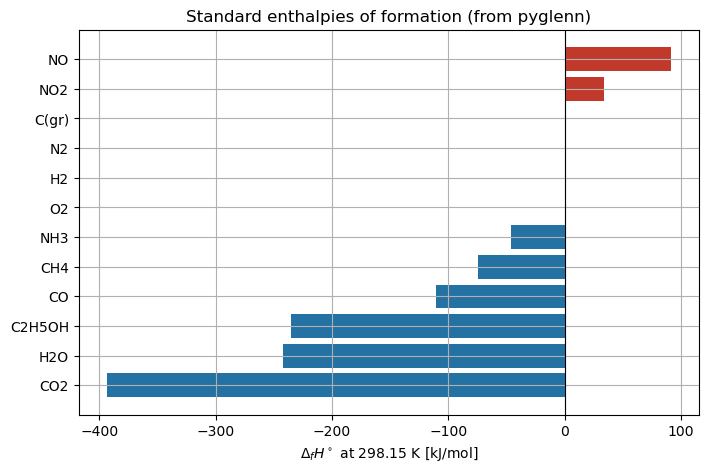

In [6]:
order = hf_df.sort_values("pyglenn [kJ/mol]")
vals = order["pyglenn [kJ/mol]"]
colors = ["#c0392b" if v > 0 else ("#7f8c8d" if abs(v) < 1e-3 else "#2471a3")
          for v in vals]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(order.index, vals, color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel(r"$\Delta_f H^\circ$ at 298.15 K [kJ/mol]")
ax.set_title("Standard enthalpies of formation (from pyglenn)")
plt.show()

## 5. Only 298.15 K is "formation"

$\Delta_f H^\circ$ is defined at 298.15 K. The standardized enthalpy $H^\circ(T)$
keeps varying with temperature, but only its 298.15 K value equals the tabulated
formation enthalpy. For CO₂ we plot $H^\circ(T)$ and highlight that reference
point; the vertical offset above it is the *sensible* enthalpy
$H^\circ(T)-H^\circ(298.15)$ from notebook 03.

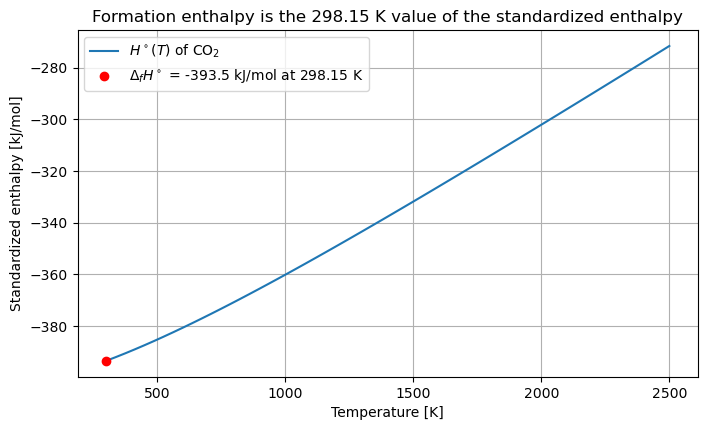

In [7]:
Tgrid = np.linspace(300, 2500, 60)
with ThermochemicalCalculator() as calc:
    co2 = calc.get_available_species("CO2", exact_match=True)[0]["id"]
    H = np.array([calc.calculate_properties(co2, t)["h_relative"] for t in Tgrid]) / 1000.0
    hf298 = formation_enthalpy(calc, "CO2") / 1000.0

fig, ax = plt.subplots()
ax.plot(Tgrid, H, label=r"$H^\circ(T)$ of CO$_2$")
ax.scatter([298.15], [hf298], color="red", zorder=5,
           label=fr"$\Delta_f H^\circ$ = {hf298:.1f} kJ/mol at 298.15 K")
ax.set_xlabel("Temperature [K]")
ax.set_ylabel("Standardized enthalpy [kJ/mol]")
ax.set_title("Formation enthalpy is the 298.15 K value of the standardized enthalpy")
ax.legend()
plt.show()

## Summary

- `calculate_formation_enthalpy` returns `None` here (empty database column).
- Use `calculate_properties(id, 298.15)["h_relative"]` instead — it equals
  $\Delta_f H^\circ$ and reproduces literature values to < 1 kJ/mol.
- Because $H^\circ$ already carries formation enthalpy, reaction enthalpies
  become trivial sums.

**Next:** notebook 05 uses exactly this to compute reaction enthalpies and heats
of combustion.